## 2026_Winter_DL_week5_Homework
CNN 실습 예제코드입니다!

이번 5주차 숙제는 총 2가지로 구성되어 있습니다.
- 논문 리뷰 - ResNet : https://arxiv.org/abs/1512.03385
    - 다음 논문을 읽고 팀별로 논문 스터디 및 정리를 준비해주시면 됩니다! (notion 이나 ppt 로 논문 정리 자료 제작 후에 팀별로 git에 업로드 해주세요 :D)

- 코드 과제 (아래 두 가지 중 택1!)
    - 1) (CNN 을 처음 접해보시거나 기초를 더 다지고 싶은 분들께 추천)
        - 아래 실습코드를 그대로 참고하셔도 좋고, 새롭게 짜셔도 좋습니다. 데이터셋은 CIFAR10이 아닌 벤치마크(MNIST, FFHQ, ImageNet)이나 다른 데이터셋을 사용하되, 학습 시간 및 리소스를 적절히 사용할 수 있는 화질을 사용하는 것을 추천 드립니다. 또한, 앞서 배운 regularization, initialization, optimizer 등등 기법을 추가해보시거나, layer를 변형하는 시도를 추가하여 결과를 분석해주세요.
        - example : Earlystopping 추가, Dropoutlayer 추가, batch nomalization 추가, stride 및 padding 변형, Conv layer 추가 및 삭제 등등
    - 2) (이미 CNN 지식이 있는 분들)
        - ResNet 을 논문 "**만**" 읽고 핵심 모듈 코드를 직접 짜보세요! 코드를 보지 않고 conv block이나 layer들을 논문 기반으로 짜보시면 됩니다.(임교수님께서 추천해주신 공부법입니다 ㅎㅎ)

In [2]:
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.optim import Adam, AdamW
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


1. 데이터셋

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

full_train = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

class_names = full_train.classes

# Train 54,000 / Validation 6,000
n_total = len(full_train)
n_val = 6000
generator = torch.Generator().manual_seed(SEED)
indices = torch.randperm(n_total, generator=generator).tolist()

val_indices = indices[:n_val]
train_indices = indices[n_val:]

train_data = Subset(full_train, train_indices)
val_data = Subset(full_train, val_indices)

BATCH_SIZE = 128

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)
test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("train:", len(train_data))
print("validation:", len(val_data))
print("test:", len(test_data))

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 171kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.17MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.2MB/s]

train: 54000
validation: 6000
test: 10000


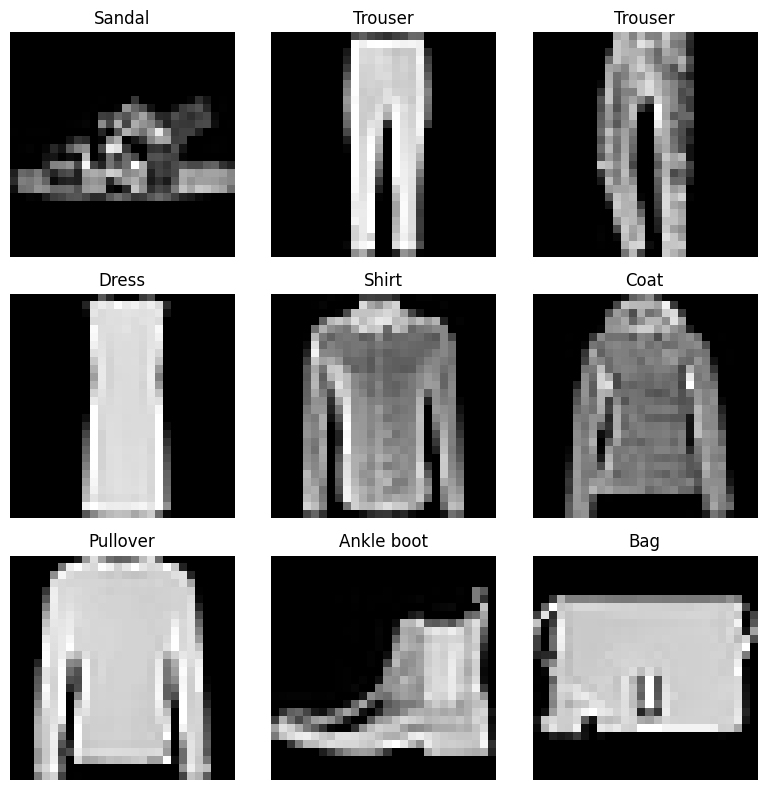

input shape: torch.Size([1, 28, 28])


In [4]:
# 데이터 확인
images, labels = next(iter(train_loader))

plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    img = images[i].squeeze().numpy()
    img = img * 0.5 + 0.5  # unnormalize
    plt.imshow(img, cmap="gray")
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

print("input shape:", images[0].shape)

2. Baseline CNN

In [5]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),   # 28 -> 14

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)    # 14 -> 7
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

3. Batch Normalization + Initialization

In [6]:
def init_kaiming(module):
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
        if module.bias is not None:
            nn.init.zeros_(module.bias)


class BatchNormCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

        self.apply(init_kaiming)

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

4. Regularized CNN

*   Batch Normalization
*   Kaiming initialization
*   Dropout2d / Dropout
*   AdamW
*   Weight decay
*   Early stopping

In [7]:
class RegularizedCNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.30):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(p=0.10),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(p=0.15)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(128, num_classes)
        )

        self.apply(init_kaiming)

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

5. Train / Validation 함수

In [8]:
criterion = nn.CrossEntropyLoss()


def evaluate(model, loader):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)
            loss = criterion(logits, labels)

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_count += batch_size

    return total_loss / total_count, total_correct / total_count


def train_model(
    model,
    optimizer,
    max_epochs=15,
    early_stopping=False,
    patience=3
):
    model = model.to(device)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    wait = 0

    for epoch in range(1, max_epochs + 1):
        model.train()

        running_loss = 0.0
        running_correct = 0
        running_count = 0

        for images, labels in tqdm(
            train_loader,
            desc=f"Epoch {epoch}/{max_epochs}",
            leave=False
        ):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            logits = model(images)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            running_correct += (logits.argmax(dim=1) == labels).sum().item()
            running_count += batch_size

        train_loss = running_loss / running_count
        train_acc = running_correct / running_count
        val_loss, val_acc = evaluate(model, val_loader)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"[{epoch:02d}] "
            f"train loss={train_loss:.4f}, acc={train_acc:.4f} | "
            f"val loss={val_loss:.4f}, acc={val_acc:.4f}"
        )

        # validation loss 기준 best model 저장
        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if early_stopping and wait >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_state)
    return model, history

6. Experiment 1 — Baseline

In [9]:
torch.manual_seed(SEED)

baseline_model = BaselineCNN()
baseline_optimizer = Adam(
    baseline_model.parameters(),
    lr=1e-3
)

baseline_model, baseline_history = train_model(
    baseline_model,
    baseline_optimizer,
    max_epochs=15,
    early_stopping=False
)

Epoch 1/15:   0%|          | 0/422 [00:00<?, ?it/s]

[01] train loss=0.5126, acc=0.8168 | val loss=0.3713, acc=0.8627


Epoch 2/15:   0%|          | 0/422 [00:00<?, ?it/s]

[02] train loss=0.3177, acc=0.8870 | val loss=0.2903, acc=0.8945


Epoch 3/15:   0%|          | 0/422 [00:00<?, ?it/s]

...

[13] train loss=0.0864, acc=0.9684 | val loss=0.2632, acc=0.9225


Epoch 14/15:   0%|          | 0/422 [00:00<?, ?it/s]

[14] train loss=0.0766, acc=0.9726 | val loss=0.3259, acc=0.9105


Epoch 15/15:   0%|          | 0/422 [00:00<?, ?it/s]

[15] train loss=0.0676, acc=0.9762 | val loss=0.2722, acc=0.9183


7. Experiment 2 — BatchNorm + Initialization

In [10]:
torch.manual_seed(SEED)

bn_model = BatchNormCNN()
bn_optimizer = Adam(
    bn_model.parameters(),
    lr=1e-3
)

bn_model, bn_history = train_model(
    bn_model,
    bn_optimizer,
    max_epochs=15,
    early_stopping=False
)

Epoch 1/15:   0%|          | 0/422 [00:00<?, ?it/s]

[01] train loss=1.3220, acc=0.7806 | val loss=0.5666, acc=0.8173


Epoch 2/15:   0%|          | 0/422 [00:00<?, ?it/s]

[02] train loss=0.4546, acc=0.8495 | val loss=0.4430, acc=0.8507


Epoch 3/15:   0%|          | 0/422 [00:00<?, ?it/s]

...

[13] train loss=0.1844, acc=0.9325 | val loss=0.2863, acc=0.9077


Epoch 14/15:   0%|          | 0/422 [00:00<?, ?it/s]

[14] train loss=0.1818, acc=0.9338 | val loss=0.2887, acc=0.9075


Epoch 15/15:   0%|          | 0/422 [00:00<?, ?it/s]

[15] train loss=0.1695, acc=0.9367 | val loss=0.3092, acc=0.9022


8. Experiment 3 — Dropout + AdamW + Early Stopping

In [11]:
torch.manual_seed(SEED)

regularized_model = RegularizedCNN(dropout=0.30)
regularized_optimizer = AdamW(
    regularized_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

regularized_model, regularized_history = train_model(
    regularized_model,
    regularized_optimizer,
    max_epochs=30,
    early_stopping=True,
    patience=3
)

Epoch 1/30:   0%|          | 0/422 [00:00<?, ?it/s]

[01] train loss=1.8056, acc=0.6076 | val loss=0.5911, acc=0.7832


Epoch 2/30:   0%|          | 0/422 [00:00<?, ?it/s]

[02] train loss=0.7451, acc=0.7313 | val loss=0.4909, acc=0.8258


Epoch 3/30:   0%|          | 0/422 [00:00<?, ?it/s]

...

[28] train loss=0.2289, acc=0.9157 | val loss=0.2410, acc=0.9162


Epoch 29/30:   0%|          | 0/422 [00:00<?, ?it/s]

[29] train loss=0.2229, acc=0.9169 | val loss=0.2436, acc=0.9192


Epoch 30/30:   0%|          | 0/422 [00:00<?, ?it/s]

[30] train loss=0.2198, acc=0.9172 | val loss=0.2380, acc=0.9193
Early stopping at epoch 30


9. Test Accuracy 비교

In [12]:
experiments = {
    "Baseline": (baseline_model, baseline_history),
    "BatchNorm + He init": (bn_model, bn_history),
    "Regularized + AdamW + EarlyStopping": (
        regularized_model,
        regularized_history
    )
}

results = []

for name, (model, history) in experiments.items():
    test_loss, test_acc = evaluate(model, test_loader)

    results.append({
        "Experiment": name,
        "Epochs": len(history["train_loss"]),
        "Best Val Loss": min(history["val_loss"]),
        "Best Val Acc": max(history["val_acc"]),
        "Test Loss": test_loss,
        "Test Accuracy": test_acc
    })

results_df = pd.DataFrame(results)
results_df

,Experiment,Epochs,Best Val Loss,Best Val Acc,Test Loss,Test Accuracy
0,Baseline,15,0.230360,0.922500,0.240345,0.9166
1,BatchNorm + He init,15,0.284166,0.907667,0.294144,0.9017
2,Regularized + AdamW + EarlyStopping,30,0.233978,0.919333,0.242216,0.9146


10. Learning Curve

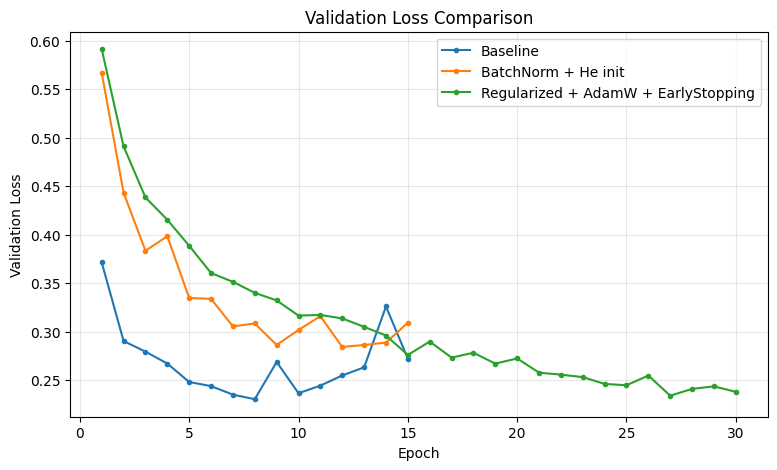

In [13]:
plt.figure(figsize=(9, 5))

for name, (_, history) in experiments.items():
    plt.plot(
        range(1, len(history["val_loss"]) + 1),
        history["val_loss"],
        marker="o",
        markersize=3,
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

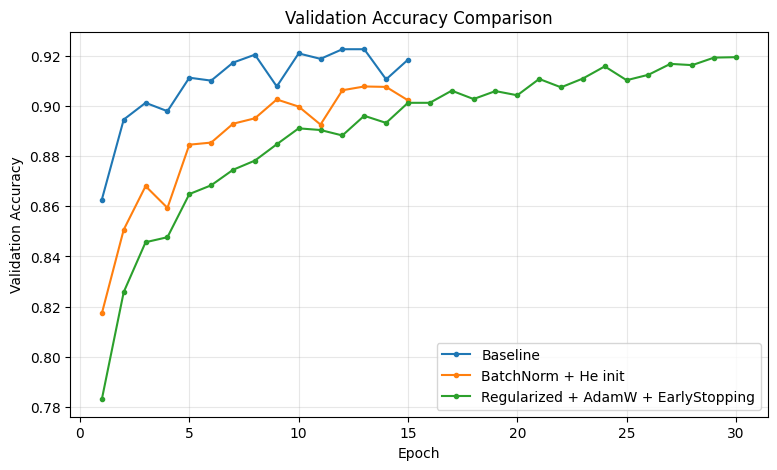

In [14]:
plt.figure(figsize=(9, 5))

for name, (_, history) in experiments.items():
    plt.plot(
        range(1, len(history["val_acc"]) + 1),
        history["val_acc"],
        marker="o",
        markersize=3,
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

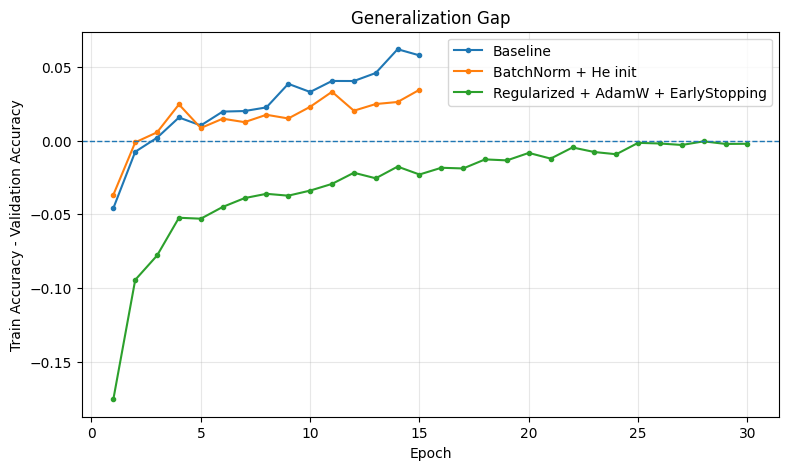

In [15]:
plt.figure(figsize=(9, 5))

for name, (_, history) in experiments.items():
    gap = np.array(history["train_acc"]) - np.array(history["val_acc"])
    plt.plot(
        range(1, len(gap) + 1),
        gap,
        marker="o",
        markersize=3,
        label=name
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Epoch")
plt.ylabel("Train Accuracy - Validation Accuracy")
plt.title("Generalization Gap")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

결론

Baseline 모델이 Test Accuracy 91.66%로 가장 높은 성능을 보였다. BatchNorm과 initialization을 적용한 모델은 90.17%로 오히려 성능이 다소 감소했다. Regularization을 적용한 모델은 91.46%로 Baseline과 유사한 성능을 보이면서 generalization gap이 가장 작아 과적합을 효과적으로 완화한 것으로 확인되었다. 따라서 본 실험에서는 baseline의 정확도가 가장 높았지만, regularization 모델이 보다 안정적인 일반화 성능을 보였다.